# Task 12: Clustering & Dimensionality Reduction

**PKCERT AI & Software Development Internship** &nbsp;|&nbsp; Author: Abdullah Amir

This notebook is **unsupervised**: K-Means and Hierarchical clustering, then PCA and
t-SNE for 2D visualisation.

The dataset is **UCI's Anuran Calls (MFCCs)**: 7,195 frog call syllables recorded in the
field, each described by 22 audio features. The frogs belong to a real **taxonomy**
(4 families, 8 genera, 10 species), which makes this a nice fit for the task: the
hierarchy in the data gives the dendrogram in Part B something real to be compared
against.

**Important:** the taxonomic labels are **never** shown to any model. They are held back
and used only *afterwards*, to score how well the clusters recovered the real structure.
That is what unsupervised learning means here, and it is what makes the scoring honest.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                             normalized_mutual_info_score)

RANDOM_STATE = 42
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

## Part A — Dataset Selection & Preparation

**What the features are.** Each row is one **syllable** of a frog call. The 22 features
are **MFCCs** (Mel-Frequency Cepstral Coefficients), the standard way to describe the
timbre of a sound: you take the short-term spectrum, warp it onto the mel scale (which
approximates how ears actually hear pitch), and compress it into a handful of
coefficients. Low coefficients capture the broad shape of the spectrum, higher ones the
finer detail. They are the same features that power speech recognition.

**Why it suits clustering.** Different frog species make genuinely different sounds, so
we would expect calls to fall into natural groups without being told the species. And
because the true taxonomy is nested (species sit inside genera, which sit inside
families), we have something meaningful to compare a dendrogram against.

In [2]:
df = pd.read_csv("frogs.csv")
MFCC = [c for c in df.columns if c.startswith("MFCC_")]
print("Shape:", df.shape, "| missing values:", int(df.isna().sum().sum()))
print(f"{len(MFCC)} MFCC features")
for c in ["Family", "Genus", "Species"]:
    print(f"  {c:8s}: {df[c].nunique()} classes")
df.head()

Shape: (7195, 26) | missing values: 0
22 MFCC features
  Family  : 4 classes
  Genus   : 8 classes
  Species : 10 classes


,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,...,MFCC_17,MFCC_18,MFCC_19,MFCC_20,MFCC_21,MFCC_22,Family,Genus,Species,RecordID
0,1.0,0.152936,-0.105586,0.200722,0.317201,0.260764,0.100945,-0.150063,-0.171128,0.124676,...,-0.108351,-0.077623,-0.009568,0.057684,0.118680,0.014038,Leptodactylidae,Adenomera,AdenomeraAndre,1
1,1.0,0.171534,-0.098975,0.268425,0.338672,0.268353,0.060835,-0.222475,-0.207693,0.170883,...,-0.090974,-0.056510,-0.035303,0.020140,0.082263,0.029056,Leptodactylidae,Adenomera,AdenomeraAndre,1
2,1.0,0.152317,-0.082973,0.287128,0.276014,0.189867,0.008714,-0.242234,-0.219153,0.232538,...,-0.050691,-0.023590,-0.066722,-0.025083,0.099108,0.077162,Leptodactylidae,Adenomera,AdenomeraAndre,1
3,1.0,0.224392,0.118985,0.329432,0.372088,0.361005,0.015501,-0.194347,-0.098181,0.270375,...,-0.136009,-0.177037,-0.130498,-0.054766,-0.018691,0.023954,Leptodactylidae,Adenomera,AdenomeraAndre,1
4,1.0,0.087817,-0.068345,0.306967,0.330923,0.249144,0.006884,-0.265423,-0.172700,0.266434,...,-0.048885,-0.053074,-0.088550,-0.031346,0.108610,0.079244,Leptodactylidae,Adenomera,AdenomeraAndre,1


In [3]:
print(df["Species"].value_counts().to_string())
print()
print(f"Recordings: {df['RecordID'].nunique()}")
print(f"Syllables per recording: min {df['RecordID'].value_counts().min()}, "
      f"max {df['RecordID'].value_counts().max()}, "
      f"median {df['RecordID'].value_counts().median():.0f}")

Species
AdenomeraHylaedactylus    3478
HypsiboasCordobae         1121
AdenomeraAndre             672
Ameeregatrivittata         542
HypsiboasCinerascens       472
HylaMinuta                 310
LeptodactylusFuscus        270
ScinaxRuber                148
OsteocephalusOophagus      114
Rhinellagranulosa           68

Recordings: 60
Syllables per recording: min 1, max 458, median 53


**Two honest caveats before we start**, both of which shape how the results should be
read.

1. **The classes are badly imbalanced.** `AdenomeraHylaedactylus` alone is 3,478 of the
   7,195 syllables, about 48%, while `Rhinellagranulosa` has just 68. Clustering
   algorithms chase density, so a class that is half the data can easily be split into
   several clusters while the rare ones get swallowed. Watch for exactly that later.
2. **The syllables are not independent.** They come from only **60 recordings**, and one
   recording contributed 458 syllables. Syllables from the same recording are the same
   individual frog in the same place at the same moment, so they are highly correlated.
   Any cluster we find may partly reflect *a particular recording* rather than *a
   species*. This is a real limitation of the data, not something a better algorithm can
   fix, and it means our scores are probably optimistic.

In [4]:
X_raw = df[MFCC].values
print("Raw MFCC range: min %.3f, max %.3f" % (X_raw.min(), X_raw.max()))
print("Per-feature std: min %.4f, max %.4f" % (X_raw.std(axis=0).min(), X_raw.std(axis=0).max()))
print("Zero-variance features:", [c for c in MFCC if df[c].std() == 0])

Raw MFCC range: min -0.952, max 1.000
Per-feature std: min 0.0690, max 0.2635
Zero-variance features: []


**Missing values and scaling.** There are no missing values, so nothing to impute. The
MFCCs already sit inside `[-1, 1]`, so it is tempting to skip scaling, but the
per-feature standard deviations still differ by roughly fourfold. Every method in this
notebook (K-Means, Ward linkage and PCA) is driven by **variance and Euclidean
distance**, so without standardising, the few high-variance coefficients would quietly
dominate the distances, the merges and the principal components alike. We standardise to
mean 0 and standard deviation 1. There are no zero-variance columns, so nothing blows up.

In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
print("After scaling: mean %.2e, std %.3f" % (X.mean(), X.std()))

y_species = df["Species"].values
y_family = df["Family"].values
y_genus = df["Genus"].values

After scaling: mean -2.51e-17, std 1.000


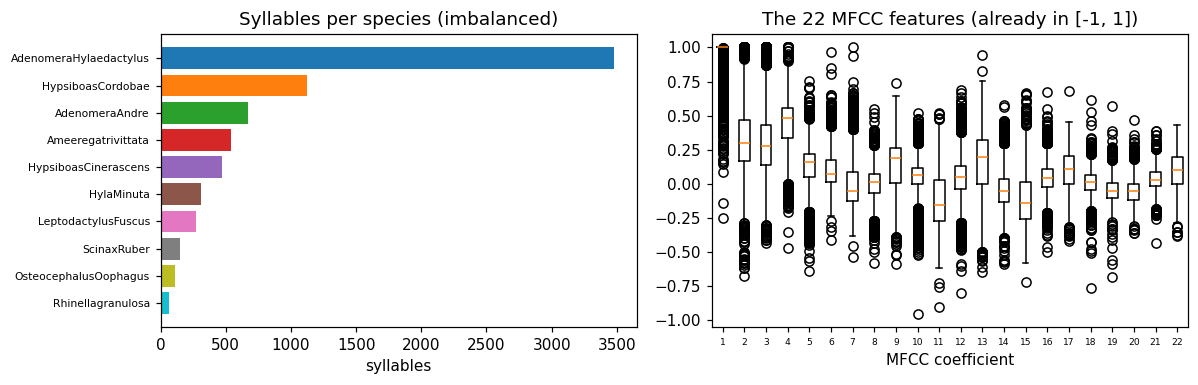

In [6]:
species_order = df["Species"].value_counts().index.tolist()
cmap10 = plt.get_cmap("tab10")
sp_color = {s: cmap10(i) for i, s in enumerate(species_order)}

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
counts = df["Species"].value_counts()
ax[0].barh([s[:22] for s in counts.index][::-1], counts.values[::-1],
           color=[sp_color[s] for s in counts.index][::-1])
ax[0].set_title("Syllables per species (imbalanced)"); ax[0].set_xlabel("syllables")
ax[0].tick_params(axis="y", labelsize=7)
ax[1].boxplot([df[c] for c in MFCC], tick_labels=[c.replace("MFCC_", "") for c in MFCC])
ax[1].set_title("The 22 MFCC features (already in [-1, 1])")
ax[1].set_xlabel("MFCC coefficient"); ax[1].tick_params(axis="x", labelsize=6)
fig.tight_layout(); plt.show()

## Part B — Clustering Techniques

### B1. K-Means, and choosing k

K-Means picks `k` centres, assigns every point to its nearest centre, moves each centre
to the mean of its members, and repeats until nothing moves. It is fast and simple, but
it carries a strong built-in assumption: that clusters are **round, similarly sized
blobs**. Hold on to that, because it explains the results.

To choose `k` we use two standard tools:

- **The elbow method:** plot `inertia` (the total squared distance from points to their
  centre) against `k`. It always falls as `k` rises, so we look for a "knee" where the
  improvement flattens out.
- **The silhouette score:** for each point, how close it is to its own cluster versus the
  nearest other cluster, ranging from -1 to +1. Higher is better, and unlike inertia it
  does not automatically improve with more clusters.

In [7]:
ks = range(2, 16)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lab = km.fit_predict(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, lab, sample_size=3000, random_state=RANDOM_STATE))
    print(f"k={k:2d}  inertia {km.inertia_:9.0f}  silhouette {sils[-1]:.4f}")

best_k_sil = list(ks)[int(np.argmax(sils))]
print(f"\nBest k by silhouette: {best_k_sil} (silhouette {max(sils):.4f})")

k= 2  inertia    108668  silhouette 0.3311


k= 3  inertia     94588  silhouette 0.3579


k= 4  inertia     84509  silhouette 0.3615


k= 5  inertia     75684  silhouette 0.3601


k= 6  inertia     67625  silhouette 0.2794


...

k=11  inertia     48958  silhouette 0.2986


k=12  inertia     46507  silhouette 0.2515


k=13  inertia     44609  silhouette 0.2574


k=14  inertia     43519  silhouette 0.2565


k=15  inertia     42222  silhouette 0.2435

Best k by silhouette: 4 (silhouette 0.3615)


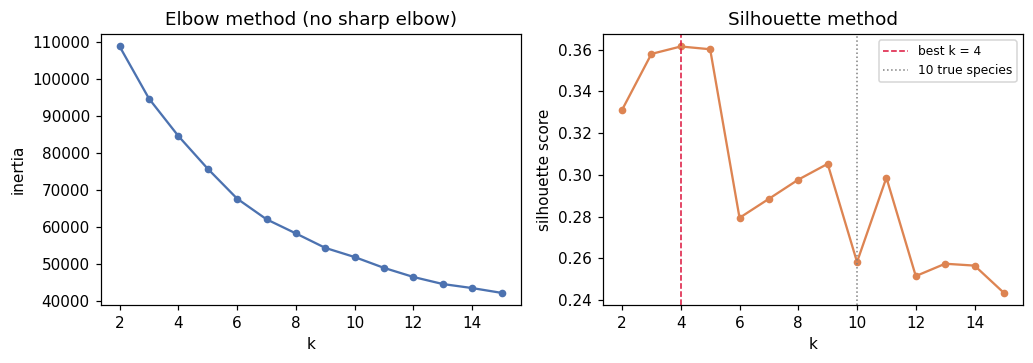

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.4))
ax[0].plot(list(ks), inertias, marker="o", ms=4, color="#4C72B0")
ax[0].set_xlabel("k"); ax[0].set_ylabel("inertia"); ax[0].set_title("Elbow method (no sharp elbow)")
ax[1].plot(list(ks), sils, marker="o", ms=4, color="#DD8452")
ax[1].axvline(best_k_sil, color="crimson", ls="--", lw=1, label=f"best k = {best_k_sil}")
ax[1].axvline(10, color="grey", ls=":", lw=1, label="10 true species")
ax[1].set_xlabel("k"); ax[1].set_ylabel("silhouette score"); ax[1].set_title("Silhouette method")
ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

**The elbow is a disappointment, and that is worth saying out loud.** The inertia curve
just bends smoothly; there is no sharp knee to point at. This is the normal case with
real data, and it is why the elbow method alone is a weak tool. The silhouette is much
more decisive: it peaks clearly at **k = 4** (0.362), with a local bump at k = 11.

So the two methods that are supposed to tell us "how many clusters" suggest **4**, when
we happen to know the truth is **10 species**. That disagreement is a genuine finding,
not a mistake, and the rest of Part B is about understanding it.

### Scoring clusters against the truth

Now we bring in the held-back labels, purely to *evaluate*. We use:

- **ARI** (Adjusted Rand Index): do the same pairs of points end up together in our
  clusters as in the truth? 1.0 is perfect, 0.0 is what random guessing gets. Crucially
  it is **adjusted for chance** and does not care how the clusters are numbered.
- **NMI** (Normalized Mutual Information): how much knowing the cluster tells you about
  the species.

In [9]:
for k in [4, 8, 10]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lab = km.fit_predict(X)
    print(f"k={k:2d}  ARI vs Family {adjusted_rand_score(y_family, lab):.3f} | "
          f"Genus {adjusted_rand_score(y_genus, lab):.3f} | "
          f"Species {adjusted_rand_score(y_species, lab):.3f}")

k= 4  ARI vs Family 0.446 | Genus 0.502 | Species 0.714


k= 8  ARI vs Family 0.284 | Genus 0.342 | Species 0.524


k=10  ARI vs Family 0.216 | Genus 0.257 | Species 0.409


Two surprises here, and both are real.

**First, k = 4 does *not* mean it found the 4 families.** That is the obvious guess and
it is wrong: at k = 4 the ARI against Family is only **0.446**, *lower* than against
Species (**0.714**). The four clusters are not the four families.

**Second, k = 4 scores far better against the 10 species than k = 10 does** (0.714
against 0.409). That sounds impossible, so it is worth being precise about why: ARI
punishes **splitting a true group across clusters** just as hard as merging two. The
dominant species is 48% of the data, and at k = 10 K-Means spends its extra centres
carving that one dense blob into pieces rather than isolating the rare species. Fewer
clusters means less fragmentation, and ARI rewards that.

Let us make the headline model (k = 10, matching the true species count) and look at
exactly that.

In [10]:
km10 = KMeans(n_clusters=10, random_state=RANDOM_STATE, n_init=10)
km_labels = km10.fit_predict(X)
km_ari = adjusted_rand_score(y_species, km_labels)
km_nmi = normalized_mutual_info_score(y_species, km_labels)
km_sil = silhouette_score(X, km_labels, sample_size=3000, random_state=RANDOM_STATE)
print(f"K-Means k=10: ARI {km_ari:.3f} | NMI {km_nmi:.3f} | silhouette {km_sil:.3f}")

pd.crosstab(pd.Series(km_labels, name="KMeans cluster"),
            pd.Series(y_species, name="Species"))

K-Means k=10: ARI 0.409 | NMI 0.613 | silhouette 0.258


Species,AdenomeraAndre,AdenomeraHylaedactylus,Ameeregatrivittata,HylaMinuta,HypsiboasCinerascens,HypsiboasCordobae,LeptodactylusFuscus,OsteocephalusOophagus,Rhinellagranulosa,ScinaxRuber
KMeans cluster,,,,,,,,,,
0,16,0,233,128,0,2,7,0,0,2
1,366,0,2,1,7,1,11,1,4,1
2,0,1113,0,58,0,5,0,0,0,0
3,3,4,0,0,430,8,0,22,3,4
4,16,1,291,59,0,978,3,45,57,120
5,0,1517,0,6,0,3,0,0,0,15
6,264,0,16,43,0,0,0,0,0,0
7,4,9,0,0,24,53,1,10,3,6
8,0,834,0,15,0,11,0,0,0,0


Read the crosstab across the `AdenomeraHylaedactylus` column: it is split across
**clusters 2, 5 and 8** (roughly 1113, 1517 and 834 syllables). K-Means burned three of
its ten clusters on one species. Meanwhile several rare species have no cluster of their
own at all. That is the fragmentation the ARI was complaining about, made concrete.

### B2. Hierarchical Clustering

Hierarchical clustering works completely differently. It starts with every point as its
own cluster and repeatedly **merges the two closest**, all the way up to one cluster,
recording the whole history as a tree. We use **Ward linkage**, which merges the pair
that increases within-cluster variance least.

The big advantages: you do **not** commit to `k` up front (you cut the tree wherever you
like afterwards), and you get the nested structure, which is exactly what we want given
that frog taxonomy is itself nested.

In [11]:
Z = linkage(X, method="ward")
hc_labels = fcluster(Z, t=10, criterion="maxclust") - 1
hc_ari = adjusted_rand_score(y_species, hc_labels)
hc_nmi = normalized_mutual_info_score(y_species, hc_labels)
hc_sil = silhouette_score(X, hc_labels, sample_size=3000, random_state=RANDOM_STATE)
print(f"Ward k=10: ARI {hc_ari:.3f} | NMI {hc_nmi:.3f} | silhouette {hc_sil:.3f}")
print()
for k in [4, 8, 10]:
    lab = fcluster(Z, t=k, criterion="maxclust") - 1
    print(f"Ward k={k:2d}  ARI vs Family {adjusted_rand_score(y_family, lab):.3f} | "
          f"Genus {adjusted_rand_score(y_genus, lab):.3f} | "
          f"Species {adjusted_rand_score(y_species, lab):.3f}")

Ward k=10: ARI 0.590 | NMI 0.719 | silhouette 0.285

Ward k= 4  ARI vs Family 0.477 | Genus 0.528 | Species 0.739
Ward k= 8  ARI vs Family 0.308 | Genus 0.348 | Species 0.529
Ward k=10  ARI vs Family 0.313 | Genus 0.402 | Species 0.590


### The dendrogram

A dendrogram draws that merge history. The height of each join is how far apart the two
merged clusters were, so **tall vertical lines mean very distinct groups**.

With 7,195 leaves the full tree is an unreadable smear, so we truncate to the last 30
merges. Each leaf is then a whole cluster, with its size in brackets.

C:\Users\User\AppData\Local\Temp\ipykernel_30440\2964857692.py:8: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout(); plt.show()


D:\Softwares\Python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


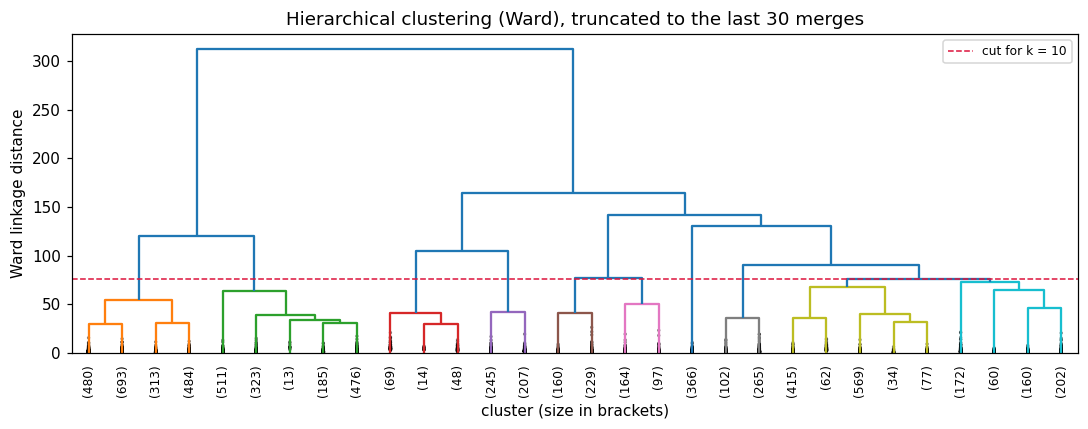

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=8,
           show_contracted=True, ax=ax, color_threshold=Z[-9, 2])
ax.set_title("Hierarchical clustering (Ward), truncated to the last 30 merges")
ax.set_xlabel("cluster (size in brackets)"); ax.set_ylabel("Ward linkage distance")
ax.axhline(Z[-9, 2], color="crimson", ls="--", lw=1, label="cut for k = 10")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

### B3. Comparing the two, and what we observe

| | K-Means (k=10) | Ward (k=10) |
|---|---|---|
| ARI vs species | 0.409 | **0.590** |
| NMI vs species | 0.613 | **0.719** |
| Silhouette | 0.258 | **0.285** |

**Ward wins on every measure**, and the margin on ARI (0.590 against 0.409) is large.
Why? Because of that assumption we flagged earlier. K-Means insists on **round, roughly
equal-sized** clusters. Frog call clusters are neither: one species has 3,478 syllables
and another has 68, and there is no reason a species' calls should form a sphere in MFCC
space. Ward makes no such assumption, so it can grow one large cluster and several tiny
ones, which is exactly the shape of this data.

This is the practical lesson: K-Means is not a worse algorithm in general, it just
encodes an assumption that this dataset violates.

In [13]:
agree = adjusted_rand_score(km_labels, hc_labels)
print(f"Agreement between K-Means and Ward (ARI): {agree:.3f}")

Agreement between K-Means and Ward (ARI): 0.554


The two methods agree with each other about as much as either agrees with the truth
(ARI 0.554). They are finding broadly the same coarse structure and disagreeing on the
details, which is reassuring: there really is signal here, and neither is hallucinating.

## Part C — Dimensionality Reduction

### C1. PCA

**PCA** is a **linear** method. It finds the directions of greatest variance in the data
and re-expresses it along those axes, in order. It is deterministic, fast, and every
component is a plain weighted sum of the original features, so the transformation is
reversible and interpretable.

In [14]:
pca_full = PCA().fit(X)
cum = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.searchsorted(cum, 0.90) + 1)
n95 = int(np.searchsorted(cum, 0.95) + 1)
print(f"PC1 {pca_full.explained_variance_ratio_[0]*100:.1f}% | "
      f"PC2 {pca_full.explained_variance_ratio_[1]*100:.1f}% | PC1+PC2 {cum[1]*100:.1f}%")
print(f"Components for 90% variance: {n90} | for 95%: {n95} (out of {len(MFCC)})")

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca2.fit_transform(X)

PC1 34.8% | PC2 15.0% | PC1+PC2 49.8%
Components for 90% variance: 9 | for 95%: 12 (out of 22)


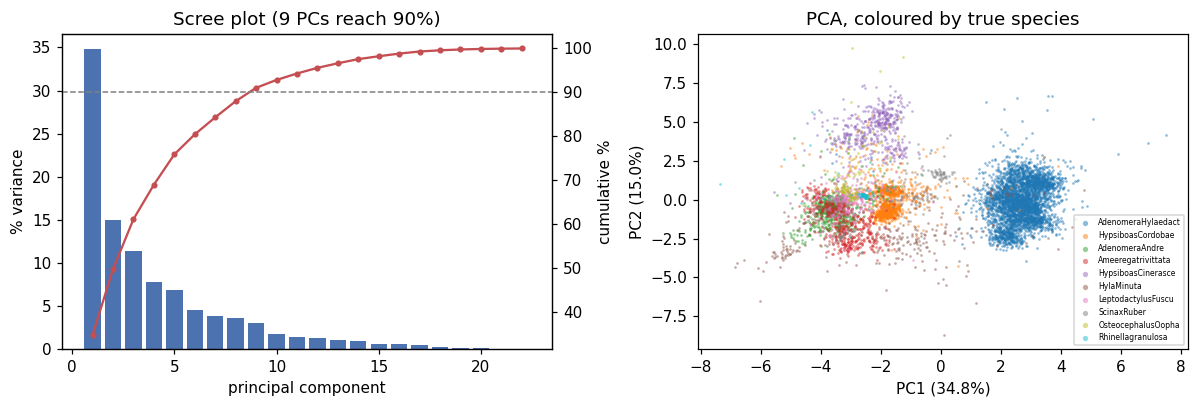

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].bar(range(1, len(MFCC) + 1), pca_full.explained_variance_ratio_ * 100, color="#4C72B0")
ax2 = ax[0].twinx()
ax2.plot(range(1, len(MFCC) + 1), cum * 100, marker="o", ms=3, color="#C44E52")
ax2.axhline(90, ls="--", lw=1, color="grey"); ax2.set_ylabel("cumulative %")
ax[0].set_xlabel("principal component"); ax[0].set_ylabel("% variance")
ax[0].set_title(f"Scree plot ({n90} PCs reach 90%)")
for s in species_order:
    m = y_species == s
    ax[1].scatter(X_pca[m, 0], X_pca[m, 1], s=3, alpha=0.5, color=sp_color[s],
                  label=s[:18], linewidths=0)
ax[1].set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)")
ax[1].set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)")
ax[1].set_title("PCA, coloured by true species")
ax[1].legend(fontsize=5, markerscale=2, framealpha=0.8)
fig.tight_layout(); plt.show()

The scree plot is informative: **PC1 carries 34.8%** and PC2 another 15.0%, so our 2D
picture shows only **49.8% of the variance**, i.e. half the information is missing from
the plot. Reaching 90% takes **9 components** and 95% takes 12, so the 22 MFCCs are
genuinely somewhat redundant, but they are not compressible to two dimensions without
real loss. That is a caution about reading too much into any 2D scatter.

### PCA as a preprocessing step

Here is where PCA earns its keep. Instead of using it just to draw a picture, we cluster
**in the 9-component space** that holds 90% of the variance:

In [16]:
pca10 = PCA(n_components=n90, random_state=RANDOM_STATE)
X_pca10 = pca10.fit_transform(X)
km_pca = KMeans(n_clusters=10, random_state=RANDOM_STATE, n_init=10).fit_predict(X_pca10)
print(f"K-Means on all 22 features: ARI {km_ari:.3f}")
print(f"K-Means on {n90} PCs        : ARI {adjusted_rand_score(y_species, km_pca):.3f}")

K-Means on all 22 features: ARI 0.409
K-Means on 9 PCs        : ARI 0.557


**Dropping 13 of the 22 dimensions made the clustering better**, from ARI 0.409 to
**0.557**. That is not a paradox. The discarded components were mostly noise, and in a
distance-based method noise in 13 directions blurs every distance you compute. Throwing
it away sharpens the real structure. This "denoise, then cluster" pattern is one of the
most useful things PCA does, and it is a much better argument for PCA than any scatter
plot.

### C2. t-SNE

**t-SNE** is **non-linear** and has a completely different goal. It does not try to
preserve variance or global geometry. It measures which points are *neighbours* in the
original 22-dimensional space and then arranges points in 2D so that those neighbourhood
relationships survive. It is built for **looking at data**, and nothing else.

In [17]:
tsne = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto",
            random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X)
print("t-SNE finished. KL divergence: %.3f" % tsne.kl_divergence_)

t-SNE finished. KL divergence: 1.210


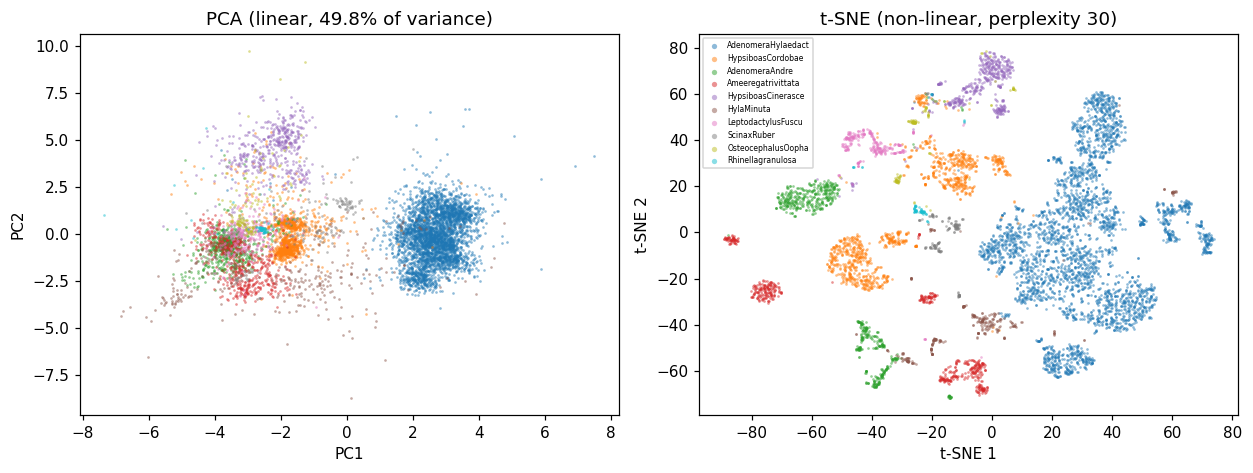

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.4))
for s in species_order:
    m = y_species == s
    ax[0].scatter(X_pca[m, 0], X_pca[m, 1], s=3, alpha=0.5, color=sp_color[s], linewidths=0)
    ax[1].scatter(X_tsne[m, 0], X_tsne[m, 1], s=3, alpha=0.5, color=sp_color[s],
                  label=s[:18], linewidths=0)
ax[0].set_title(f"PCA (linear, {cum[1]*100:.1f}% of variance)")
ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2")
ax[1].set_title("t-SNE (non-linear, perplexity 30)")
ax[1].set_xlabel("t-SNE 1"); ax[1].set_ylabel("t-SNE 2")
ax[1].legend(fontsize=5, markerscale=2, framealpha=0.8)
fig.tight_layout(); plt.show()

The visual difference is dramatic. PCA gives one smeared cloud with the species heavily
overlapping. t-SNE breaks the same data into clearly separated islands that line up
closely with real species. As a *picture*, t-SNE wins outright.

But watch what happens if we take that pretty picture literally and cluster on it:

In [19]:
km_on_pca2 = KMeans(n_clusters=10, random_state=RANDOM_STATE, n_init=10).fit_predict(X_pca)
km_on_tsne = KMeans(n_clusters=10, random_state=RANDOM_STATE, n_init=10).fit_predict(X_tsne)
print(f"K-Means on all 22 features : ARI {km_ari:.3f}")
print(f"K-Means on {n90} PCs         : ARI {adjusted_rand_score(y_species, km_pca):.3f}  <- best")
print(f"K-Means on 2D PCA          : ARI {adjusted_rand_score(y_species, km_on_pca2):.3f}")
print(f"K-Means on 2D t-SNE        : ARI {adjusted_rand_score(y_species, km_on_tsne):.3f}")

K-Means on all 22 features : ARI 0.409
K-Means on 9 PCs         : ARI 0.557  <- best
K-Means on 2D PCA          : ARI 0.378
K-Means on 2D t-SNE        : ARI 0.335


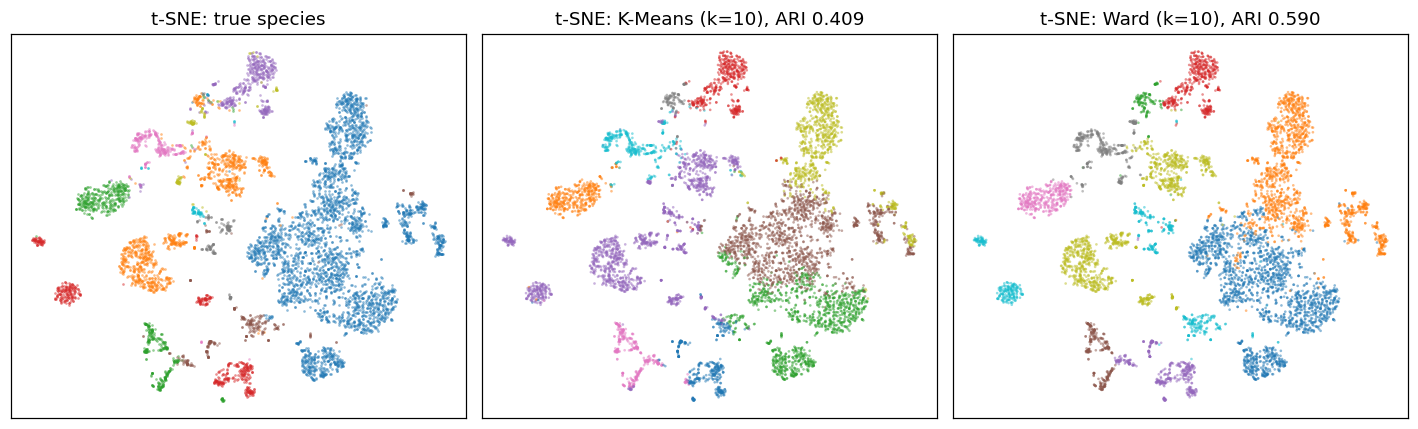

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for s in species_order:
    m = y_species == s
    ax[0].scatter(X_tsne[m, 0], X_tsne[m, 1], s=3, alpha=0.5, color=sp_color[s], linewidths=0)
ax[0].set_title("t-SNE: true species")
for a, lab, name, ari in [(ax[1], km_labels, "K-Means (k=10)", km_ari),
                          (ax[2], hc_labels, "Ward (k=10)", hc_ari)]:
    a.scatter(X_tsne[:, 0], X_tsne[:, 1], s=3, alpha=0.5, c=lab, cmap="tab10", linewidths=0)
    a.set_title(f"t-SNE: {name}, ARI {ari:.3f}")
for a in ax:
    a.set_xticks([]); a.set_yticks([])
fig.tight_layout(); plt.show()

**Clustering on the t-SNE embedding is the *worst* option of the four (ARI 0.335).** The
plot that looks the most convincing produces the weakest clusters. This is the single
most important practical point in Part C, and it is easy to get wrong.

The reason is that t-SNE's distances are not real distances. It deliberately distorts
space to make neighbourhoods visible: it inflates dense regions, compresses sparse ones,
and the gaps between its islands do **not** encode how different those groups are.
K-Means then takes those fictional distances at face value. The picture is a
visualisation, not a feature space.

### C3. PCA vs t-SNE

| | PCA | t-SNE |
|---|---|---|
| **Type** | Linear projection | Non-linear embedding |
| **Preserves** | Global structure, variance | Local neighbourhoods |
| **Deterministic?** | Yes | No, changes with seed |
| **Distances meaningful?** | Yes | **No**, between-cluster gaps are not real |
| **Speed here** | Instant | ~1 minute on 7,195 points |
| **New data?** | Yes, just project it | No, must re-run everything |
| **Interpretable?** | Yes, components are weighted sums | No, axes mean nothing |
| **ARI when clustered on** | **0.557** (at 9 PCs) | 0.335 |

**Advantages of PCA:** fast, deterministic, reversible, interpretable, it can transform
unseen data, and its axes carry a real quantity (variance explained). It also genuinely
improved our clustering.
**Limitations of PCA:** being linear, it can only rotate and project, so it cannot unfold
curved structure. Here that shows: two components hold just 49.8% of the variance and the
species overlap badly.
**Use PCA for:** compression, denoising before another algorithm, preprocessing, and any
time you need to apply the same transform to future data.

**Advantages of t-SNE:** far and away the better picture, revealing structure PCA
smears together.
**Limitations of t-SNE:** slow, stochastic, sensitive to perplexity, no way to project new
points, and its distances and gaps are not meaningful.
**Use t-SNE for:** exploring and presenting, checking whether structure exists at all.
Never as a feature space to compute on.

## Part D — Analysis & Conclusion

### What the results say

**1. The data has real structure, but not the ten neat groups you might expect.** Every
method found genuine signal (Ward reaches ARI 0.590 against species, far above chance),
but no method recovers the ten species cleanly, and the silhouette's preferred k = 4
matches neither the 4 families nor the 10 species. The honest reading: frog calls form a
handful of strongly separated acoustic groups, with finer species distinctions inside
them that are much subtler than the gaps between groups.

**2. Ward beats K-Means, because of an assumption rather than an accident.** K-Means
requires round, similar-sized clusters. This data has one species at 48% and another at
0.9%. Ward has no such requirement and wins on ARI, NMI and silhouette alike.

**3. Fewer dimensions clustered better than more.** K-Means on 9 PCs (ARI 0.557) clearly
beat K-Means on all 22 features (0.409). The dropped components were mostly noise that
was blurring the distances.

**4. The best-looking projection made the worst clusters.** t-SNE gives a beautiful,
convincing picture and the worst ARI of any option (0.335).

### Recommendation

**For clustering this dataset: Hierarchical clustering with Ward linkage, run on the
first 9 principal components.** Ward is the right choice because it does not assume
spherical, balanced clusters, and this data is emphatically neither. Reducing to 9 PCs
first is worth it because it removed noise that measurably hurt K-Means, and it makes the
distance computation cheaper too. You also do not have to commit to `k` in advance, which
matters a lot here given that none of our methods for choosing `k` agreed.

**For visualising this dataset: t-SNE, but only for visualising.** It is the only method
that makes the structure legible. Use it to look and to present, then go back to the
real feature space (or PCA of it) to actually compute. Do not cluster on it.

**PCA earns its place in the middle**, not as the visualisation (at 49.8% of variance in
2D it is honestly a poor picture) but as the preprocessing step that made the clustering
better.

### The caveat that matters most

All of these scores are probably **optimistic**, and it would be dishonest to present
them without saying so. The 7,195 syllables come from only **60 recordings**, so
syllables from one recording are the same individual frog, recorded in one moment, and
are far more alike than two random members of a species would be. Some of what our
clusters "discovered" is almost certainly *this particular frog on this particular
evening*, not *this species*. A stricter evaluation would group syllables by `RecordID`
and check whether clusters survive across different recordings of the same species. With
only 3 to 11 recordings per species, that test would be underpowered, which is itself a
limit of the dataset rather than of the methods.

The broader lesson is the one running through the whole notebook: in unsupervised
learning there is no accuracy score to hide behind. The metrics disagreed with each
other, the prettiest plot was the least trustworthy, and the "right" number of clusters
was never found. Reading the results honestly matters more than any single number.